<a href="https://colab.research.google.com/github/Sujita-Acharyya123/sentiment-analysis-project/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries installed!
✅ All imports done!
📁 Click 'Choose Files' and upload your: IMDB Dataset.csv


Saving IMDB Dataset.csv to IMDB Dataset.csv
✅ File uploaded!
  DATASET LOADED SUCCESSFULLY
  Total Reviews : 49,999
  Columns       : ['review', 'sentiment', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
  Missing Values: 599976

Sentiment Counts:
sentiment
positive         24999
negative         24999
 Jim Abrahams        1
Name: count, dtype: int64

✅ Text cleaning done!

Example — BEFORE cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Example — AFTER cleaning:
One of the other reviewers has mentioned that after watching just Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its
⏳ Running TextBlob... (3-5 minutes, pleas

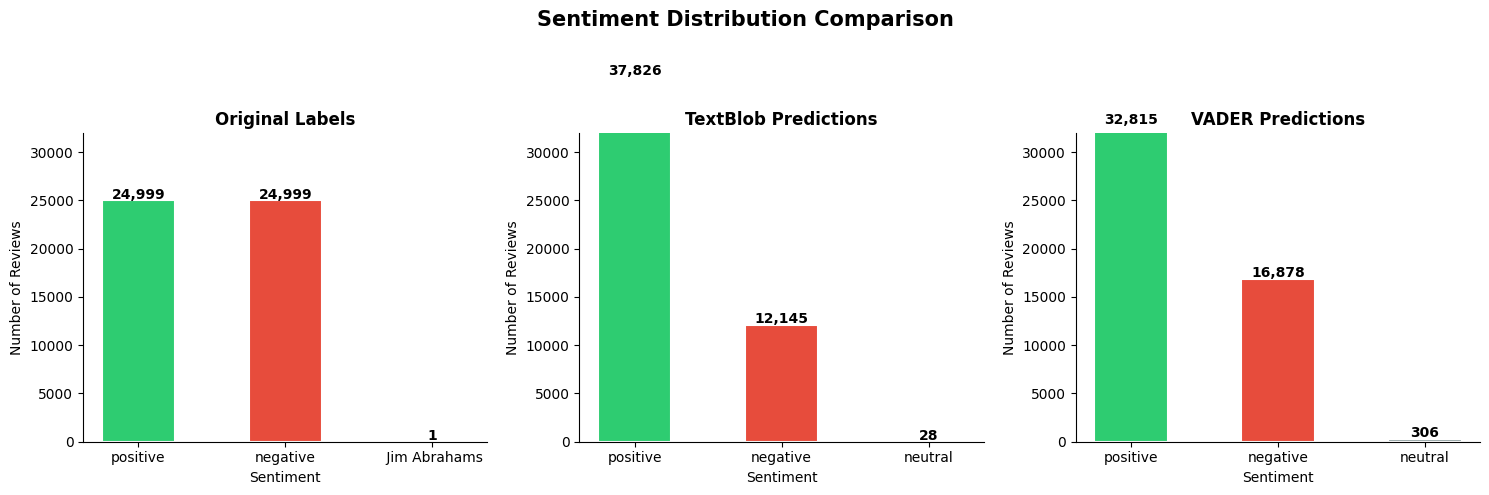

✅ Saved: chart1_distribution.png


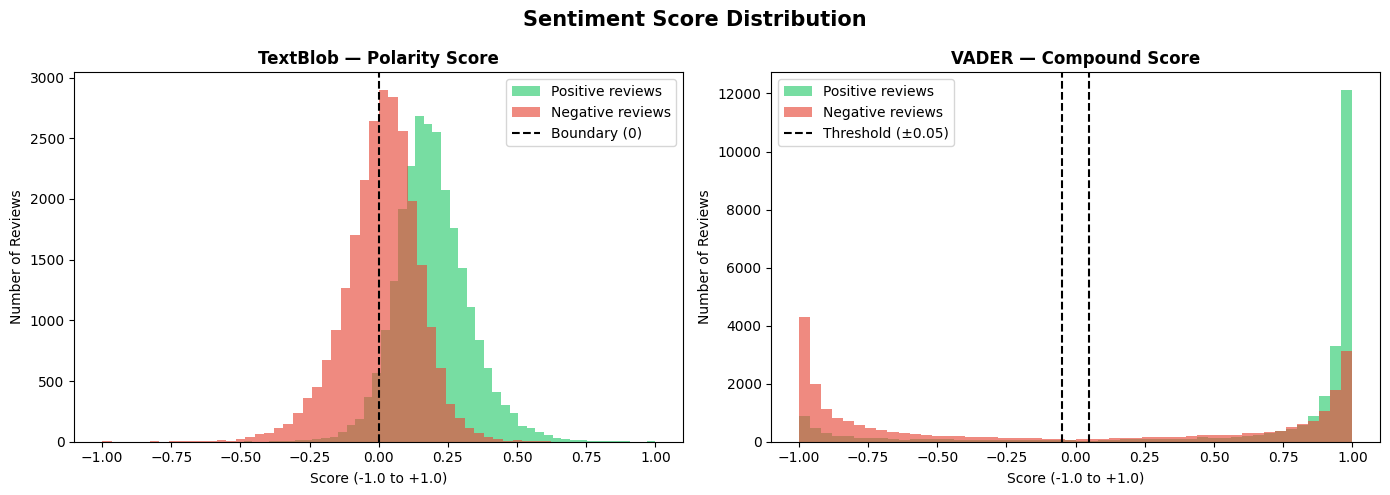

✅ Saved: chart2_scores.png


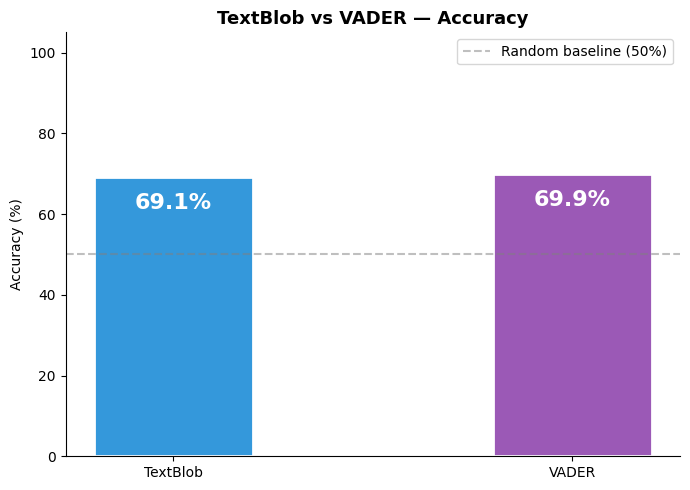

✅ Saved: chart3_accuracy.png


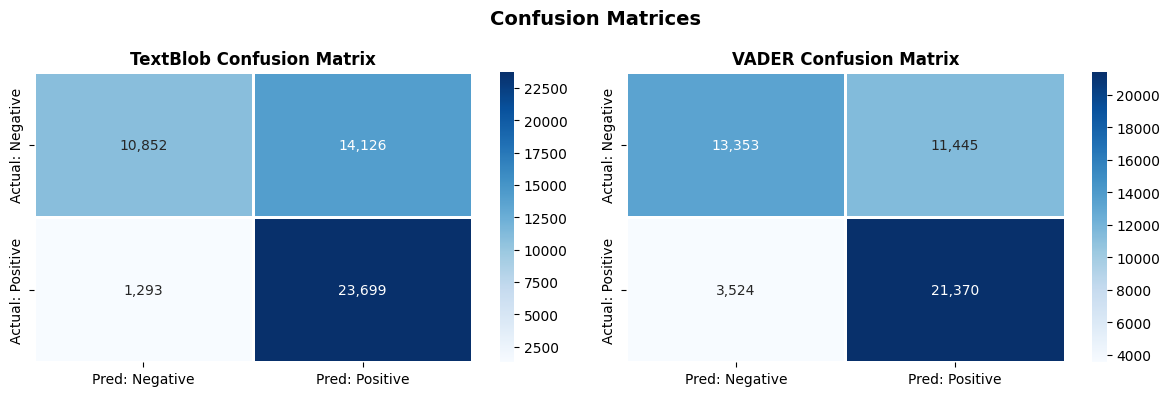

✅ Saved: chart4_confusion.png


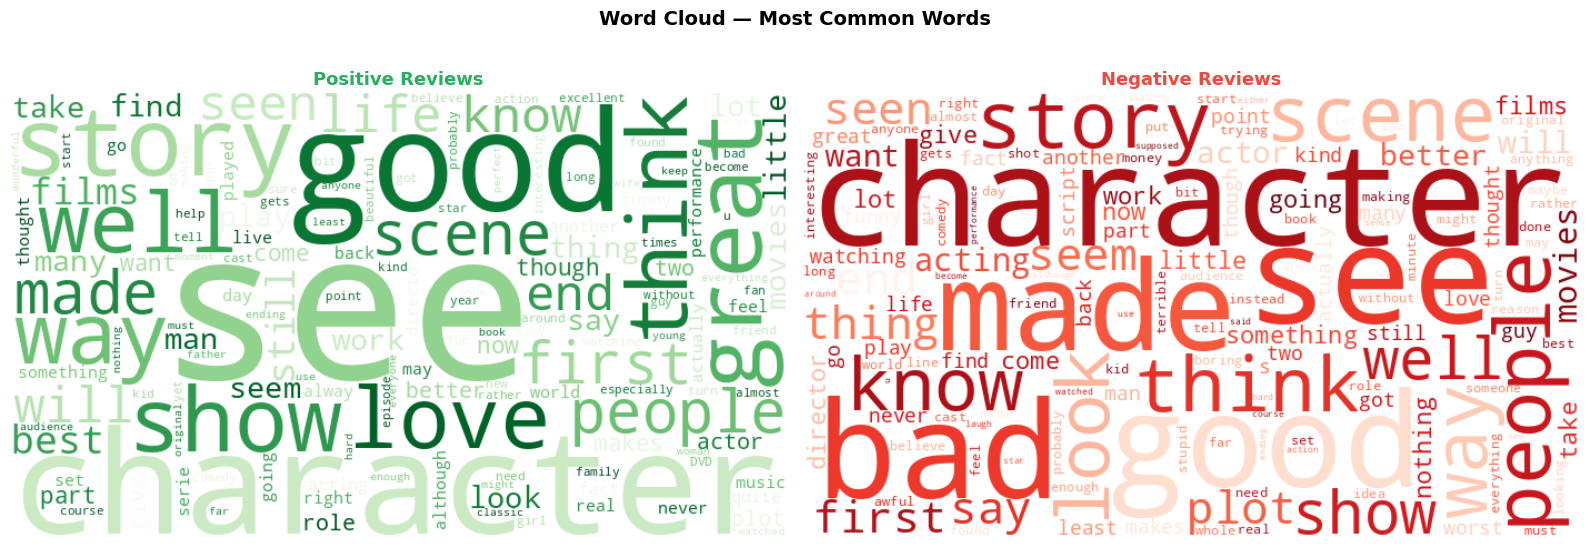

✅ Saved: chart5_wordcloud.png
  YOUR TEXT ANALYSIS
  Text : This movie was absolutely amazing! I loved every second of it.

  ── TextBlob ──────────────────────────────
  Polarity Score    : +0.483
  Subjectivity Score: 0.567
  Result            : ✅ POSITIVE

  ── VADER ─────────────────────────────────
  Compound Score    : +0.861
  Result            : ✅ POSITIVE
✅ Results saved — 49,999 rows in results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Downloaded: chart4_confusion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: chart5_wordcloud.png


In [ ]:




!pip install textblob --quiet
!pip install wordcloud --quiet

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ All libraries installed!")



import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

print("✅ All imports done!")



from google.colab import files


print("📁 Click 'Choose Files' and upload your: IMDB Dataset.csv")
uploaded = files.upload()
print("✅ File uploaded!")



df = pd.read_csv('IMDB Dataset.csv')

print("=" * 40)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 40)
print(f"  Total Reviews : {len(df):,}")
print(f"  Columns       : {df.columns.tolist()}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print("=" * 40)
print()
print("Sentiment Counts:")
print(df['sentiment'].value_counts())
print()
df.head(3)



def clean_text(text):
    # Remove HTML tags like <br />
    text = re.sub(r'<.*?>', ' ', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s\.!\?,\'\":-]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)

print("✅ Text cleaning done!")
print()
print("Example — BEFORE cleaning:")
print(df['review'][0][:200])
print()
print("Example — AFTER cleaning:")
print(df['clean_review'][0][:200])



print("⏳ Running TextBlob... (3-5 minutes, please wait)")

def get_textblob(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        label = 'positive'
    elif score < 0:
        label = 'negative'
    else:
        label = 'neutral'
    return score, label

results = df['clean_review'].apply(get_textblob)
df['tb_score']     = results.apply(lambda x: x[0])
df['tb_sentiment'] = results.apply(lambda x: x[1])

print("✅ TextBlob done!")
print()
print("TextBlob Results:")
print(df['tb_sentiment'].value_counts())



print("⏳ Running VADER... (1-2 minutes, please wait)")

def get_vader(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        label = 'positive'
    elif score <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return score, label

results = df['clean_review'].apply(get_vader)
df['vader_score']     = results.apply(lambda x: x[0])
df['vader_sentiment'] = results.apply(lambda x: x[1])

print("✅ VADER done!")
print()
print("VADER Results:")
print(df['vader_sentiment'].value_counts())



def get_accuracy(pred_col, name):
    # Only check positive/negative (skip neutral)
    mask    = df[pred_col] != 'neutral'
    subset  = df[mask]
    correct = (subset[pred_col] == subset['sentiment']).sum()
    total   = len(subset)
    acc     = correct / total * 100
    print(f"  {name}")
    print(f"    Accuracy  : {acc:.2f}%")
    print(f"    Classified: {total:,} reviews")
    print(f"    Neutral   : {(df[pred_col] == 'neutral').sum():,} reviews skipped")
    print()
    return acc

print("=" * 40)
print("   ACCURACY REPORT")
print("=" * 40)
tb_acc    = get_accuracy('tb_sentiment',    'TextBlob')
vader_acc = get_accuracy('vader_sentiment', 'VADER')



fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sentiment Distribution Comparison', fontsize=15, fontweight='bold')

datasets = [
    ('Original Labels',      'sentiment'),
    ('TextBlob Predictions', 'tb_sentiment'),
    ('VADER Predictions',    'vader_sentiment'),
]

color_map = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}

for ax, (title, col) in zip(axes, datasets):
    counts = df[col].value_counts()
    colors = [color_map.get(s, '#3498db') for s in counts.index]
    bars   = ax.bar(counts.index, counts.values, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 150,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Number of Reviews')
    ax.set_ylim(0, 32000)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart1_distribution.png")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Score Distribution', fontsize=15, fontweight='bold')

# TextBlob
axes[0].hist(df[df['sentiment'] == 'positive']['tb_score'],
             bins=50, alpha=0.65, color='#2ecc71', label='Positive reviews')
axes[0].hist(df[df['sentiment'] == 'negative']['tb_score'],
             bins=50, alpha=0.65, color='#e74c3c', label='Negative reviews')
axes[0].axvline(0, color='black', linestyle='--', lw=1.5, label='Boundary (0)')
axes[0].set_title('TextBlob — Polarity Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score (-1.0 to +1.0)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# VADER
axes[1].hist(df[df['sentiment'] == 'positive']['vader_score'],
             bins=50, alpha=0.65, color='#2ecc71', label='Positive reviews')
axes[1].hist(df[df['sentiment'] == 'negative']['vader_score'],
             bins=50, alpha=0.65, color='#e74c3c', label='Negative reviews')
axes[1].axvline( 0.05, color='black', linestyle='--', lw=1.5, label='Threshold (±0.05)')
axes[1].axvline(-0.05, color='black', linestyle='--', lw=1.5)
axes[1].set_title('VADER — Compound Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score (-1.0 to +1.0)')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart2_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart2_scores.png")



fig, ax = plt.subplots(figsize=(7, 5))

tools      = ['TextBlob', 'VADER']
accuracies = [tb_acc, vader_acc]
colors     = ['#3498db', '#9b59b6']

bars = ax.bar(tools, accuracies, color=colors,
              edgecolor='white', linewidth=2, width=0.4)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 4,
            f'{acc:.1f}%',
            ha='center', va='top',
            fontsize=16, fontweight='bold', color='white')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Random baseline (50%)')
ax.set_title('TextBlob vs VADER — Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart3_accuracy.png")



from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['tb_sentiment', 'vader_sentiment'],
    ['TextBlob', 'VADER']
):
    mask   = df[col] != 'neutral'
    subset = df[mask]
    cm     = confusion_matrix(subset['sentiment'], subset[col],
                              labels=['negative', 'positive'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Pred: Negative', 'Pred: Positive'],
                yticklabels=['Actual: Negative', 'Actual: Positive'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{title} Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart4_confusion.png")



stop_words = set(STOPWORDS)
stop_words.update(['movie', 'film', 'one', 'even', 'much',
                   'really', 'would', 'also', 'get', 'like',
                   'br', 'just', 'watch', 'make', 'time'])

pos_text = ' '.join(df[df['sentiment'] == 'positive']['clean_review'])
neg_text = ' '.join(df[df['sentiment'] == 'negative']['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Cloud — Most Common Words', fontsize=14, fontweight='bold')

wc_pos = WordCloud(width=700, height=400, background_color='white',
                   stopwords=stop_words, colormap='Greens',
                   max_words=150).generate(pos_text)
wc_neg = WordCloud(width=700, height=400, background_color='white',
                   stopwords=stop_words, colormap='Reds',
                   max_words=150).generate(neg_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews', fontsize=13,
                  fontweight='bold', color='#27ae60')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews', fontsize=13,
                  fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.savefig('chart5_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart5_wordcloud.png")




my_text = "This movie was absolutely amazing! I loved every second of it."


cleaned  = clean_text(my_text)
tb_score = TextBlob(cleaned).sentiment.polarity
tb_subj  = TextBlob(cleaned).sentiment.subjectivity
v_score  = sia.polarity_scores(cleaned)['compound']

tb_result = '✅ POSITIVE' if tb_score > 0 else ('❌ NEGATIVE' if tb_score < 0 else '➖ NEUTRAL')
v_result  = '✅ POSITIVE' if v_score >= 0.05 else ('❌ NEGATIVE' if v_score <= -0.05 else '➖ NEUTRAL')

print("=" * 55)
print("  YOUR TEXT ANALYSIS")
print("=" * 55)
print(f"  Text : {my_text[:65]}..." if len(my_text) > 65 else f"  Text : {my_text}")
print()
print("  ── TextBlob ──────────────────────────────")
print(f"  Polarity Score    : {tb_score:+.3f}")
print(f"  Subjectivity Score: {tb_subj:.3f}")
print(f"  Result            : {tb_result}")
print()
print("  ── VADER ─────────────────────────────────")
print(f"  Compound Score    : {v_score:+.3f}")
print(f"  Result            : {v_result}")
print("=" * 55)



df[['review', 'clean_review', 'sentiment',
    'tb_score', 'tb_sentiment',
    'vader_score', 'vader_sentiment']].to_csv('results.csv', index=False)

print(f"✅ Results saved — {len(df):,} rows in results.csv")


from google.colab import files
for f in ['results.csv',
          'chart1_distribution.png',
          'chart2_scores.png',
          'chart3_accuracy.png',
          'chart4_confusion.png',
          'chart5_wordcloud.png']:
    try:
        files.download(f)
        print(f"  ✅ Downloaded: {f}")
    except:
        print(f"  ⚠️  Could not download: {f}")